Qwen3 Mixture-of-Experts From Scratch (A Standalone Notebook)
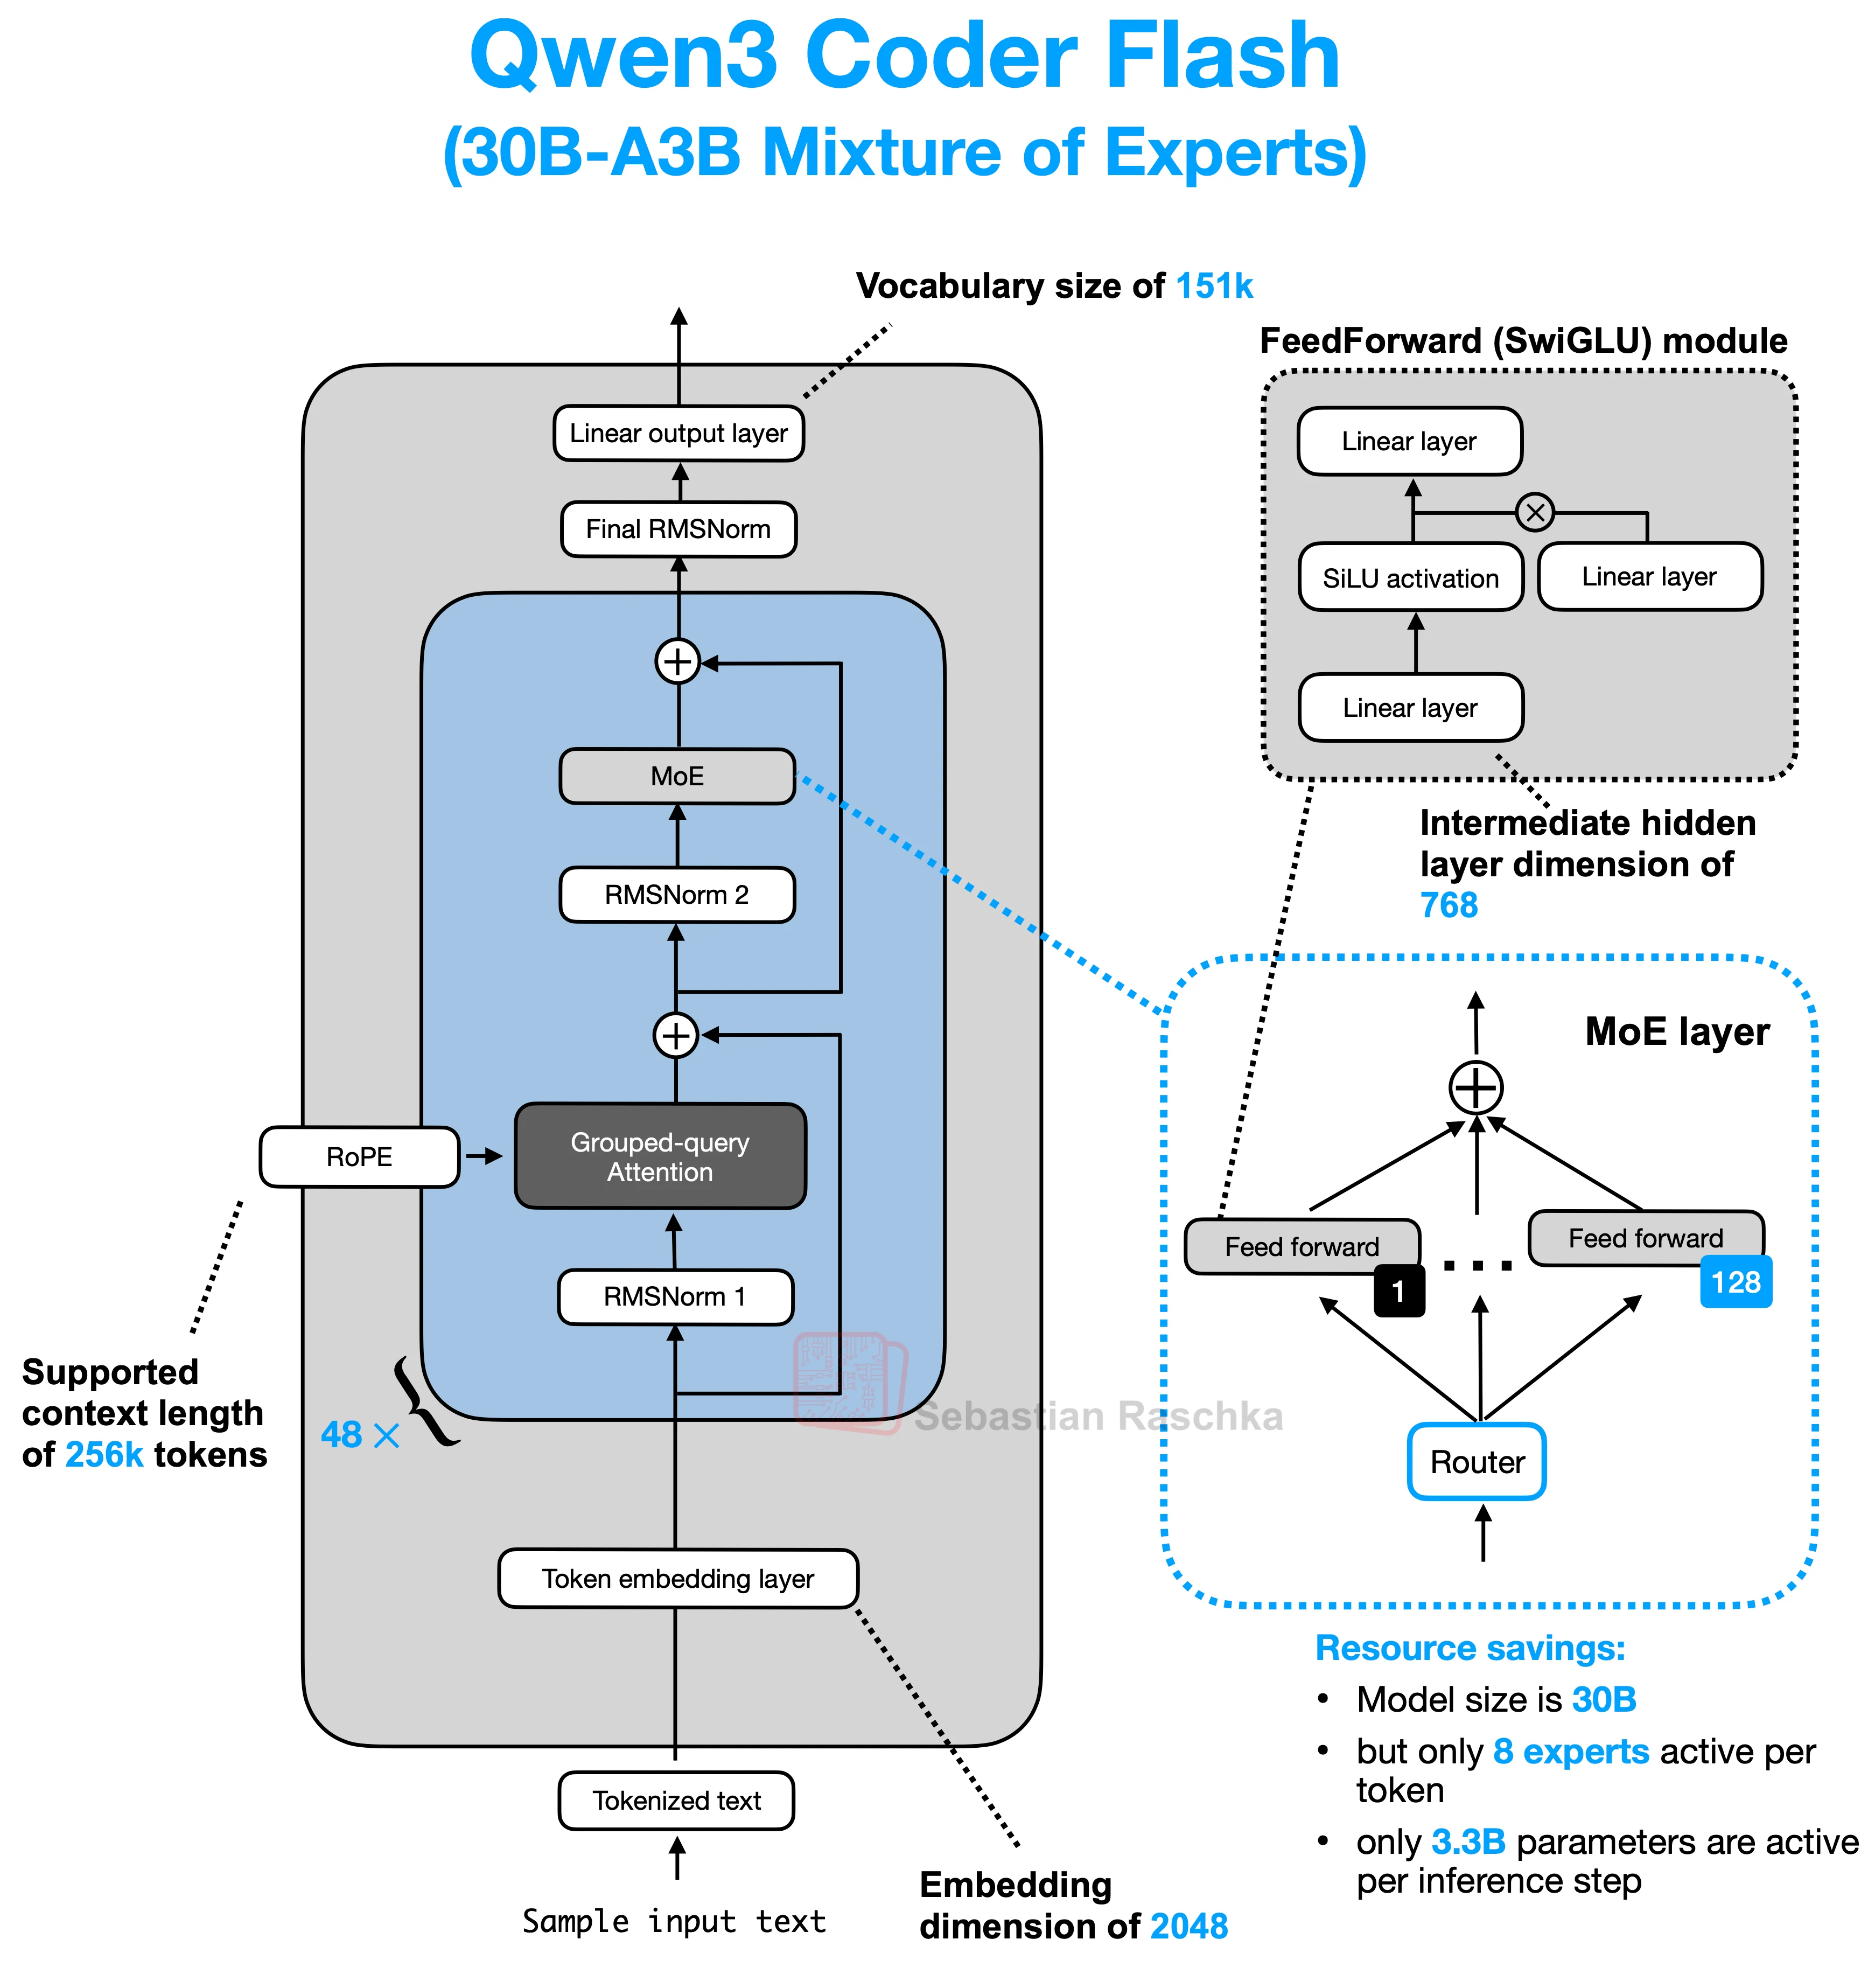

In [ ]:
from importlib.metadata import version

# 打印关键依赖库的版本号,确保下载权重(huggingface_hub)、
# 分词(tokenizers)、建模与张量运算(torch)所需的库版本符合预期
pkgs = [
    "huggingface_hub",  # to download pretrained weights
    "tokenizers",       # to implement the tokenizer
    "torch",            # to implement the model
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

1. Architecture code

In [ ]:
import torch
import torch.nn as nn


class FeedForward(nn.Module):
    # 标准的 SwiGLU 前馈网络(用于非 MoE 层,或作为对比参考):
    # fc1 作为“门控”分支、fc2 作为“上投影”分支,二者形状相同,
    # 用 SiLU 激活门控分支后与上投影分支逐元素相乘,再通过 fc3 投影回 emb_dim
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"], bias=False)

    def forward(self, x):
        # x: (batch, seq_len, emb_dim)
        x_fc1 = self.fc1(x)  # (batch, seq_len, hidden_dim) —— 门控分支
        x_fc2 = self.fc2(x)  # (batch, seq_len, hidden_dim) —— 上投影分支
        x = nn.functional.silu(x_fc1) * x_fc2  # SwiGLU: silu(gate) * up
        return self.fc3(x)  # 投影回 (batch, seq_len, emb_dim)


class MoEFeedForward(nn.Module):
    # 混合专家(Mixture-of-Experts)前馈网络:
    # 用一个路由器(gate)为每个 token 打分,挑出得分最高的 top-k 个专家,
    # 只让这 k 个专家处理该 token,再按 softmax 权重加权求和多个专家的输出。
    # 这样可以在增大总参数量(专家数量)的同时,保持每个 token 的实际计算量
    # (激活的专家数)不变,即“稀疏激活”。
    def __init__(self, cfg):
        super().__init__()
        self.num_experts_per_tok = cfg["num_experts_per_tok"]  # 每个 token 激活的专家数 top-k
        self.num_experts = cfg["num_experts"]  # 专家总数
        self.emb_dim = cfg["emb_dim"]
        # 路由器(gate/router):把每个 token 的隐藏向量映射到 num_experts 个打分上
        self.gate = nn.Linear(cfg["emb_dim"], cfg["num_experts"], bias=False, dtype=cfg["dtype"])

        # 每个专家都是一个 SwiGLU MLP:
        # fc1 -> 门控投影(对应权重文件中的 gate_proj)
        # fc2 -> 上投影(对应权重文件中的 up_proj)
        # fc3 -> 下投影,把 moe_hidden_dim 投回 emb_dim(对应 down_proj)
        # 用 ModuleList 为每个专家分别保存一套独立参数
        self.fc1 = nn.ModuleList([nn.Linear(cfg["emb_dim"], cfg["moe_hidden_dim"], bias=False, dtype=cfg["dtype"])
                                  for _ in range(cfg["num_experts"])])
        self.fc2 = nn.ModuleList([nn.Linear(cfg["emb_dim"], cfg["moe_hidden_dim"], bias=False, dtype=cfg["dtype"])
                                  for _ in range(cfg["num_experts"])])
        self.fc3 = nn.ModuleList([nn.Linear(cfg["moe_hidden_dim"], cfg["emb_dim"], bias=False, dtype=cfg["dtype"])
                                  for _ in range(cfg["num_experts"])])

    def forward(self, x):
        # x: (batch, seq_len, emb_dim)
        scores = self.gate(x)  # (b, seq_len, num_experts)  路由打分
        # 对每个 token,在 num_experts 个打分中选出得分最高的 top-k 个专家及其打分
        topk_scores, topk_indices = torch.topk(scores, self.num_experts_per_tok, dim=-1)
        # 只在被选中的 top-k 个专家之间做 softmax,得到归一化的专家组合权重
        # topk_scores/topk_indices/topk_probs 形状均为 (b, seq_len, num_experts_per_tok)
        topk_probs = torch.softmax(topk_scores, dim=-1)

        batch, seq_len, _ = x.shape
        # 把 (batch, seq_len) 两个维度展平成一个“token”维度,方便按 token 做专家分派
        x_flat = x.reshape(batch * seq_len, -1)  # (batch*seq_len, emb_dim)
        # 用于累加每个 token 的最终 MoE 输出(先置零,再逐专家累加)
        out_flat = torch.zeros(batch * seq_len, self.emb_dim, device=x.device, dtype=x.dtype)

        # 同步展平专家索引与对应权重,行维度与 x_flat 对齐
        topk_indices_flat = topk_indices.reshape(-1, self.num_experts_per_tok)  # (batch*seq_len, k)
        topk_probs_flat = topk_probs.reshape(-1, self.num_experts_per_tok)      # (batch*seq_len, k)

        # 找出当前 batch 中实际被用到的专家编号(避免遍历全部 num_experts,提升效率)
        unique_experts = torch.unique(topk_indices_flat)

        for expert_id_tensor in unique_experts:
            expert_id = int(expert_id_tensor.item())
            # mask: 该专家是否出现在每个 token 的 top-k 选择里,形状 (batch*seq_len, k)
            mask = topk_indices_flat == expert_id
            if not mask.any():
                continue

            # token_mask: 对每个 token,只要它的 top-k 中包含当前专家就为 True
            token_mask = mask.any(dim=-1)
            # 取出被路由到当前专家的所有 token 在展平序列中的下标
            selected_idx = token_mask.nonzero(as_tuple=False).squeeze(-1)
            if selected_idx.numel() == 0:
                continue

            # 只对被选中的 token 做该专家的前向计算(而不是对所有 token 计算再丢弃),
            # 这正是 MoE 稀疏计算、节省算力的关键所在
            expert_input = x_flat.index_select(0, selected_idx)  # (num_selected, emb_dim)
            # 专家内部同样是 SwiGLU: silu(fc1(x)) * fc2(x),再经 fc3 投影回 emb_dim
            hidden = torch.nn.functional.silu(self.fc1[expert_id](expert_input)) * self.fc2[expert_id](expert_input)
            expert_out = self.fc3[expert_id](hidden)  # (num_selected, emb_dim)

            # 由于一个 token 的 top-k 中,当前专家可能出现在不同的“槽位”(第几个 top-k),
            # 需要找到对应槽位,取出该专家在这些 token 上的组合权重
            mask_selected = mask[selected_idx]  # (num_selected, k)
            slot_indices = mask_selected.int().argmax(dim=-1, keepdim=True)  # 该专家所在的槽位下标
            selected_probs = torch.gather(
                topk_probs_flat.index_select(0, selected_idx), dim=-1, index=slot_indices
            ).squeeze(-1)  # (num_selected,) 当前专家对应的 softmax 权重

            # 按权重把当前专家的输出累加回对应 token 的位置(多个专家的贡献会依次累加)
            out_flat.index_add_(0, selected_idx, expert_out * selected_probs.unsqueeze(-1))

        # 还原回 (batch, seq_len, emb_dim) 的形状
        return out_flat.reshape(batch, seq_len, self.emb_dim)

In [ ]:
class RMSNorm(nn.Module):
    # RMSNorm(均方根归一化):相比 LayerNorm 不减均值,只用均方根做缩放,
    # 计算更简单、开销更小,是 LLaMA/Qwen 等现代 LLM 的标配归一化方式。
    # 这里同时被用作:
    #   1) Transformer 每个子层前的 Pre-Norm(norm1 / norm2 / final_norm)
    #   2) 注意力内部的 QK-Norm(对每个 head 的 query/key 向量做归一化,
    #      用来稳定训练、缓解注意力分数过大或过小的问题)
    def __init__(self, emb_dim, eps=1e-6, bias=False, qwen3_compatible=True):
        super().__init__()
        self.eps = eps
        self.qwen3_compatible = qwen3_compatible
        self.scale = nn.Parameter(torch.ones(emb_dim))  # 可学习的缩放参数(逐通道)
        self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None  # 可选的可学习偏置

    def forward(self, x):
        input_dtype = x.dtype

        # Qwen3 为了数值稳定性,在计算方差前先转成 float32,算完再转回原 dtype
        if self.qwen3_compatible:
            x = x.to(torch.float32)

        # 沿最后一维(特征维,可以是 emb_dim 也可以是 head_dim)计算均方值
        variance = x.pow(2).mean(dim=-1, keepdim=True)
        # 用均方根的倒数做缩放,实现归一化(不像 LayerNorm 那样先减均值)
        norm_x = x * torch.rsqrt(variance + self.eps)
        norm_x = norm_x * self.scale  # 逐通道可学习缩放

        if self.shift is not None:
            norm_x = norm_x + self.shift  # 可选的逐通道可学习偏置

        return norm_x.to(input_dtype)

In [ ]:
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, dtype=torch.float32):
    # 预计算 RoPE(旋转位置编码)所需的 cos/sin 表。
    # RoPE 的思路:把 query/key 向量的每一对相邻(此实现是“前半/后半”配对)分量
    # 看作二维平面上的一个点,按位置索引乘以一个旋转角度做旋转,
    # 从而把“绝对位置”信息编码为向量的旋转角度,同时使注意力分数天然具备相对位置特性。
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    # 每一对维度使用不同的频率:频率随维度指数衰减(类似 Transformer 的正弦位置编码),
    # inv_freq 形状: (head_dim // 2,)
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    # Generate position indices
    # 位置索引 0, 1, ..., context_length-1
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles
    # 外积:每个位置 × 每个频率 = 该位置在该频率下的旋转角度
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    # 把角度复制一份拼接,使角度表的最后一维扩展到完整的 head_dim,
    # 前半部分和后半部分使用相同角度,方便下面 apply_rope 中按“前半/后半”配对旋转
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    # 预先算好每个位置、每个维度对应的 cos/sin,推理时直接查表相乘,避免重复计算
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


def apply_rope(x, cos, sin, offset=0):
    # 对 query 或 key 张量施加旋转位置编码。
    # offset 用于增量解码(KV cache)场景:新 token 在完整序列中的起始位置,
    # 保证新 token 使用与其“真实位置”对应的旋转角度,而不是总是从 0 开始。
    # x: (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    # 把 head_dim 一分为二,(x1, x2) 对应旋转公式里的“实部、虚部”配对
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2:]  # Second half

    # Adjust sin and cos shapes
    # 根据 offset 取出当前这批 token 对应位置区间的 cos/sin,
    # 并 unsqueeze 出 batch 和 head 维度以便广播
    cos = cos[offset:offset + seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[offset:offset + seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    # 标准旋转变换: [x1, x2] -> [x1*cos - x2*sin, x2*cos + x1*sin]
    # 这里用 rotated = [-x2, x1] 与 [x, rotated] 结合 cos/sin 的写法等价地实现同样的旋转
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    # It's ok to use lower-precision after applying cos and sin rotation
    return x_rotated.to(dtype=x.dtype)

In [ ]:
class GroupedQueryAttention(nn.Module):
    # 分组查询注意力(Grouped-Query Attention, GQA):
    # 多个 query head 共享同一组 key/value head(而不是像 MHA 那样每个 query head
    # 都有独立的 key/value),从而大幅减少 KV 的存储量和 KV cache 显存占用,
    # 同时相比 MQA(所有 head 共享一组 KV)保留了更多的表达能力。
    def __init__(
        self, d_in, num_heads, num_kv_groups, head_dim=None, qk_norm=False, dtype=None
    ):
        super().__init__()
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        # 每一组 kv head 需要被多少个 query head 共享
        self.group_size = num_heads // num_kv_groups

        if head_dim is None:
            assert d_in % num_heads == 0, "`d_in` must be divisible by `num_heads` if `head_dim` is not set"
            head_dim = d_in // num_heads

        self.head_dim = head_dim
        self.d_out = num_heads * head_dim

        # Q 投影到全部 num_heads 个头;K/V 只投影到 num_kv_groups 个“组”,
        # 因此 K/V 的参数量和后续 KV cache 大小都远小于 Q
        self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)

        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, dtype=dtype)

        if qk_norm:
            # QK-Norm: 对每个 head 的 query / key 向量(维度为 head_dim)分别做 RMSNorm,
            # 用来稳定注意力分数的数值范围,是 Qwen3 相比早期模型新增的细节
            self.q_norm = RMSNorm(head_dim, eps=1e-6)
            self.k_norm = RMSNorm(head_dim, eps=1e-6)
        else:
            self.q_norm = self.k_norm = None

    def forward(self, x, mask, cos, sin, start_pos=0, cache=None):
        # x: (b, num_tokens, d_in); num_tokens 在有 KV cache 时通常只是新增的 1 个（或若干个）token
        b, num_tokens, _ = x.shape

        # Apply projections
        queries = self.W_query(x)  # (b, num_tokens, num_heads * head_dim)
        keys = self.W_key(x)       # (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)   # (b, num_tokens, num_kv_groups * head_dim)

        # Reshape
        # 拆分出 head 维度,并把 head 维放到 seq_len 前面,方便按 head 做批量矩阵乘法
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)      # (b, num_heads, num_tokens, head_dim)
        keys_new = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)    # (b, num_kv_groups, num_tokens, head_dim)
        values_new = values.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)  # (b, num_kv_groups, num_tokens, head_dim)

        # Optional normalization
        # QK-Norm 在 RoPE 之前对 q/k 做归一化(按最后一维 head_dim 归一化)
        if self.q_norm:
            queries = self.q_norm(queries)
        if self.k_norm:
            keys_new = self.k_norm(keys_new)

        # Apply RoPE
        # 用 start_pos 作为 offset,保证在增量解码时新 token 拿到正确的绝对位置编码
        queries = apply_rope(queries, cos, sin, offset=start_pos)
        keys_new = apply_rope(keys_new, cos, sin, offset=start_pos)

        if cache is not None:
            # KV cache 增量解码:把历史缓存的 key/value 与本次新算出的 key/value
            # 在序列长度维(dim=2)拼接,得到“历史 + 当前”完整的 key/value,
            # 这样每一步只需要为新 token 计算一次 K/V,而不用重新计算整个历史序列
            prev_k, prev_v = cache
            keys = torch.cat([prev_k, keys_new], dim=2)    # (b, num_kv_groups, total_seen, head_dim)
            values = torch.cat([prev_v, values_new], dim=2)
            next_cache = (keys, values)  # 更新后的缓存,供下一层/下一步使用
        else:
            start_pos = 0  # reset RoPE
            keys, values = keys_new, values_new
            next_cache = (keys, values)  # 即便不使用外部 cache,也返回本次的 K/V 供上层选择是否缓存

        # Expand K and V to match number of heads
        # 把每组 kv head 沿 head 维复制 group_size 次,从而与 num_heads 个 query head 一一对应
        # (GQA 的核心操作:多个 query head 复用同一份 key/value)
        keys = keys.repeat_interleave(self.group_size, dim=1)     # (b, num_heads, total_seen, head_dim)
        values = values.repeat_interleave(self.group_size, dim=1)  # (b, num_heads, total_seen, head_dim)

        # Attention
        # 缩放点积注意力: (b, num_heads, num_tokens, total_seen)
        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)  # 用因果掩码屏蔽“看到未来”的位置
        attn_weights = torch.softmax(attn_scores / self.head_dim**0.5, dim=-1)

        # 加权求和得到上下文向量,再拼回所有 head,形状还原为 (b, num_tokens, d_out)
        context = (attn_weights @ values).transpose(1, 2).reshape(b, num_tokens, self.d_out)
        return self.out_proj(context), next_cache

In [ ]:
class TransformerBlock(nn.Module):
    # 单个 Transformer 层:Pre-Norm 结构,依次是
    # (RMSNorm -> GQA 自注意力 -> 残差) + (RMSNorm -> FeedForward/MoE -> 残差)
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            head_dim=cfg["head_dim"],
            num_kv_groups=cfg["n_kv_groups"],
            qk_norm=cfg["qk_norm"],
            dtype=cfg["dtype"]
        )
        # 若配置了专家数量(num_experts > 0),使用 MoE 前馈层;否则退化为普通稠密 FeedForward
        if cfg["num_experts"] > 0:
            self.ff = MoEFeedForward(cfg)
        else:
            self.ff = FeedForward(cfg)
        self.norm1 = RMSNorm(cfg["emb_dim"], eps=1e-6)  # 注意力前的 Pre-Norm
        self.norm2 = RMSNorm(cfg["emb_dim"], eps=1e-6)  # 前馈网络前的 Pre-Norm

    def forward(self, x, mask, cos, sin, start_pos=0, cache=None):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        # start_pos / cache 透传给注意力层,用于 RoPE 位置偏移和 KV cache 的读写
        x, next_cache = self.att(x, mask, cos, sin, start_pos=start_pos, cache=cache)  # Shape [batch_size, num_tokens, emb_size]
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = x + shortcut  # Add the original input back

        return x, next_cache

In [ ]:
class Qwen3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Main model parameters
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])

        self.trf_blocks = nn.ModuleList(  # ModuleList since Sequential can only accept one input, and we need `x, mask, cos, sin`
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = RMSNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        # Reusable utilities
        if cfg["head_dim"] is None:
            head_dim = cfg["emb_dim"] // cfg["n_heads"]
        else:
            head_dim = cfg["head_dim"]
        # 提前算好整段 context_length 内的 RoPE cos/sin 表,所有层共享同一份
        cos, sin = compute_rope_params(
            head_dim=head_dim,
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"]
        )
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        self.cfg = cfg
        self.current_pos = 0  # Track current position in KV cache  —— 记录 KV cache 中已生成到的绝对位置


    def forward(self, in_idx, cache=None):
        # Forward pass
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        num_tokens = x.shape[1]  # 本次前向传入的 token 数(首轮是整段 prompt,之后每次通常只有 1 个新 token)
        if cache is not None:
            # 使用 KV cache 的增量解码模式:
            # pos_start/pos_end 标记本次新 token 在“完整序列”中的绝对位置区间
            pos_start = self.current_pos
            pos_end = pos_start + num_tokens
            self.current_pos = pos_end  # 更新下一次调用时的起始位置
            # 构造因果掩码:完整的下三角掩码是 (pos_end, pos_end),
            # 但本次只需要“新 token 对已见过的所有位置(含自身)”这部分,
            # 因此切片取 [pos_start:pos_end, :pos_end] —— 形状 (num_tokens, pos_end)
            mask = torch.triu(
                torch.ones(pos_end, pos_end, device=x.device, dtype=torch.bool), diagonal=1
            )[pos_start:pos_end, :pos_end]
        else:
            # 不使用 KV cache(一次性对整段序列做前向,如首次 prime cache 或非流式推理):
            # 标准的下三角因果掩码,形状 (num_tokens, num_tokens)
            pos_start = 0  # Not strictly necessary but helps torch.compile
            mask = torch.triu(
                torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1
            )
        # Shape (1, 1, num_tokens, num_tokens) to broadcast across batch and heads
        # 增加 batch 和 head 两个维度,便于在注意力计算中广播到 (b, num_heads, ...)
        mask = mask[None, None, :, :]

        for i, block in enumerate(self.trf_blocks):
            # 从外部传入的 KVCache 中取出第 i 层已缓存的 (key, value);首次调用为 None
            blk_cache = cache.get(i) if cache else None
            x, new_blk_cache = block(x, mask, self.cos, self.sin,
                                     start_pos=pos_start,
                                     cache=blk_cache)
            if cache is not None:
                # 把本层拼接了新 token 之后的 (key, value) 写回缓存,供下一次调用复用
                cache.update(i, new_blk_cache)

        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits

    def reset_kv_cache(self):
        # 开始新一轮生成前,把位置计数器清零(需配合外部新建/reset 一个 KVCache 一起使用)
        self.current_pos = 0

In [ ]:
class KVCache:
    # 简单的按层存储的 KV 缓存容器:
    # 每一层的缓存是一个 (key, value) 张量元组,形状均为
    # (batch, num_kv_groups, seen_so_far, head_dim),随着生成推进不断在 seq 维上增长
    def __init__(self, n_layers):
        self.cache = [None] * n_layers  # 每层一个槽位,初始为空(还没有历史 KV)

    def get(self, layer_idx):
        return self.cache[layer_idx]

    def update(self, layer_idx, value):
        self.cache[layer_idx] = value

    def get_all(self):
        return self.cache

    def reset(self):
        # 清空所有层的缓存,用于开始新一轮独立的生成
        for i in range(len(self.cache)):
            self.cache[i] = None

2. Initialize model

In [ ]:
# Same config for

# https://huggingface.co/Qwen/Qwen3-Coder-30B-A3B-Instruct (Qwen3 Coder Flash)
# https://huggingface.co/Qwen/Qwen3-30B-A3B-Thinking-2507
# https://huggingface.co/Qwen/Qwen3-235B-A22B-Instruct-2507
# https://huggingface.co/Qwen/Qwen3-30B-A3B (original Instruct/Thinking hybrid model)

# 模型结构超参数配置字典,后续构建 Qwen3Model 与加载权重都依赖这份配置
QWEN3_CONFIG = {
    "vocab_size": 151_936,       # 词表大小
    "context_length": 262_144,   # 支持的最大上下文长度(RoPE 预计算表的长度)
    "emb_dim": 2048,             # 词嵌入/隐藏层维度
    "n_heads": 32,               # 注意力 query head 数量
    "n_layers": 48,              # Transformer 层数
    "head_dim": 128,             # 每个注意力头的维度
    "qk_norm": True,             # 是否启用 QK-Norm(对 q/k 做 RMSNorm)
    "n_kv_groups": 4,            # GQA 的 key/value 组数(共享组数,越小 KV cache 越省显存)
    "rope_base": 10_000_000.0,   # RoPE 的 theta_base,决定旋转频率的基数
    "dtype": torch.bfloat16,     # 权重/计算使用的精度
    "num_experts": 128,          # MoE 专家总数
    "num_experts_per_tok": 8,    # 每个 token 实际激活(top-k)的专家数
    "moe_hidden_dim": 768,       # 每个专家内部 SwiGLU 的隐藏层维度
}

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

In [ ]:
torch.manual_seed(123)

# 在 `with device:` 上下文中创建模型,PyTorch 会直接在目标 device 上分配参数,
# 避免先在 CPU 创建整个大模型再搬运到 GPU/MPS 带来的双倍显存/内存峰值
with device:
    model = Qwen3Model(QWEN3_CONFIG)

#model.to(device)

In [ ]:
# 用一个随机构造的极短序列做一次前向计算,验证模型结构与形状是否搭建正确
# (此时权重仍是随机初始化,未加载预训练参数,输出 logits 本身没有语义意义)
model(torch.tensor([1, 2, 3]).unsqueeze(0).to(device))

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

# Account for weight tying
# 若输出层 out_head 与词嵌入 tok_emb 权重共享(weight tying),
# 二者会被重复计入 total_params,这里减去一份词嵌入参数量得到“去重后”的参数量
total_params_normalized = total_params - model.tok_emb.weight.numel()
print(f"\nTotal number of unique parameters: {total_params_normalized:,}")

In [ ]:
def calc_model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    # 缓冲区(如 RoPE 预计算的 cos/sin 表)不是可训练参数,但同样占用显存/内存
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    # 假设参数、梯度都用同一种 dtype 存储,估算总字节数(推理场景通常没有梯度,total_grads 近似为 0)
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

print(f"float32 (PyTorch default): {calc_model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {calc_model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

3. Load pretrained weights

In [ ]:
def load_weights_into_qwen(model, param_config, params):
    # 把 HuggingFace 官方 safetensors 权重字典(键名如 "model.layers.0...")
    # 逐一拷贝赋值到本notebook自定义的 Qwen3Model 对应模块的参数上
    def assign(left, right, tensor_name="unknown"):
        if left.shape != right.shape:
            raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

        with torch.no_grad():
            if isinstance(right, torch.Tensor):
                left.copy_(right)
            else:
                left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

        return left

    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):
        block = model.trf_blocks[l]
        att = block.att

        # Q, K, V projections
        att.W_query.weight = assign(
            att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        att.W_key.weight = assign(
            att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        att.W_value.weight = assign(
            att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )

        # Output projection
        att.out_proj.weight = assign(
            att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )

        # QK norms
        # 对应 GroupedQueryAttention 中启用 qk_norm 时创建的 q_norm / k_norm 的 scale 参数
        if hasattr(att, "q_norm") and att.q_norm is not None:
            att.q_norm.scale = assign(
                att.q_norm.scale,
                params[f"model.layers.{l}.self_attn.q_norm.weight"],
                f"model.layers.{l}.self_attn.q_norm.weight"
            )
        if hasattr(att, "k_norm") and att.k_norm is not None:
            att.k_norm.scale = assign(
                att.k_norm.scale,
                params[f"model.layers.{l}.self_attn.k_norm.weight"],
                f"model.layers.{l}.self_attn.k_norm.weight"
            )

        # Attention layernorm
        block.norm1.scale = assign(
            block.norm1.scale,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Feedforward weights
        if "num_experts" in param_config and param_config["num_experts"] > 0:
            # Load router (gating) weights
            # MoE 路由器权重,对应 MoEFeedForward.gate
            block.ff.gate.weight = assign(
                block.ff.gate.weight,
                params[f"model.layers.{l}.mlp.gate.weight"],
                f"model.layers.{l}.mlp.gate.weight"
            )
            # Load expert weights
            # 逐个专家加载:gate_proj -> fc1, up_proj -> fc2, down_proj -> fc3
            for e in range(param_config["num_experts"]):
                prefix = f"model.layers.{l}.mlp.experts.{e}"
                block.ff.fc1[e].weight = assign(
                    block.ff.fc1[e].weight,
                    params[f"{prefix}.gate_proj.weight"],
                    f"{prefix}.gate_proj.weight"
                )
                block.ff.fc2[e].weight = assign(
                    block.ff.fc2[e].weight,
                    params[f"{prefix}.up_proj.weight"],
                    f"{prefix}.up_proj.weight"
                )
                block.ff.fc3[e].weight = assign(
                    block.ff.fc3[e].weight,
                    params[f"{prefix}.down_proj.weight"],
                    f"{prefix}.down_proj.weight"
                )

        else:
            # 非 MoE(稠密 FeedForward)情况下的普通权重加载
            block.ff.fc1.weight = assign(
                block.ff.fc1.weight,
                params[f"model.layers.{l}.mlp.gate_proj.weight"],
                f"model.layers.{l}.mlp.gate_proj.weight"
            )
            block.ff.fc2.weight = assign(
                block.ff.fc2.weight,
                params[f"model.layers.{l}.mlp.up_proj.weight"],
                f"model.layers.{l}.mlp.up_proj.weight"
            )
            block.ff.fc3.weight = assign(
                block.ff.fc3.weight,
                params[f"model.layers.{l}.mlp.down_proj.weight"],
                f"model.layers.{l}.mlp.down_proj.weight"
            )

        block.norm2.scale = assign(
            block.norm2.scale,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Final normalization and output head
    model.final_norm.scale = assign(model.final_norm.scale, params["model.norm.weight"], "model.norm.weight")

    if "lm_head.weight" in params:
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        # 若权重文件中没有独立的 lm_head,说明该模型使用权重共享(weight tying),
        # 输出层直接复用词嵌入矩阵
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")

In [ ]:
import json
import os
from pathlib import Path
from safetensors.torch import load_file
from huggingface_hub import snapshot_download

repo_id = "Qwen/Qwen3-30B-A3B"  # Original Instruct/Thinking hybrind model
repo_id = "Qwen/Qwen3-235B-A22B-Instruct-2507"  # New instruct model
repo_id = "Qwen/Qwen3-30B-A3B-Thinking-2507"  # New thinking model
repo_id = "Qwen/Qwen3-Coder-30B-A3B-Instruct"  # (Qwen3 Coder Flash)

local_dir = Path(repo_id).parts[-1]

# 从 HuggingFace Hub 下载模型仓库(权重分片 + 索引文件等)到本地目录
repo_dir = snapshot_download(repo_id=repo_id, local_dir=local_dir)
# index.json 记录了每个权重张量名称对应存放在哪个 safetensors 分片文件里
index_path = os.path.join(repo_dir, "model.safetensors.index.json")
with open(index_path, "r") as f:
    index = json.load(f)

weights_dict = {}
# 遍历所有涉及到的分片文件(用 set 去重,避免重复加载同一个分片),
# 把各分片中的张量合并到一个统一的 weights_dict 中
for filename in set(index["weight_map"].values()):
    shard_path = os.path.join(repo_dir, filename)
    shard = load_file(shard_path)
    weights_dict.update(shard)

# 按照前面定义的映射规则,把 HuggingFace 权重逐一拷贝进自定义模型结构
load_weights_into_qwen(model, QWEN3_CONFIG, weights_dict)
model.to(device);

4. Load tokenizer

In [ ]:
import re
from tokenizers import Tokenizer

class Qwen3Tokenizer:
    # 基于 HuggingFace `tokenizers` 库的 BPE 分词器封装,
    # 额外处理 Qwen 系列特殊 token(如对话标记、思维链标记等)以及聊天模板包装
    _SPECIALS = [
        "<|endoftext|>",
        "<|im_start|>", "<|im_end|>",
        "<|object_ref_start|>", "<|object_ref_end|>",
        "<|box_start|>", "<|box_end|>",
        "<|quad_start|>", "<|quad_end|>",
        "<|vision_start|>", "<|vision_end|>",
        "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>",
        "<think>", "</think>"
    ]
    # 用于在编码前把文本中出现的特殊 token 片段切分出来,单独处理(不送入 BPE 子词切分)
    _SPLIT_RE = re.compile(r"(<\|[^>]+?\|>|<think>|</think>)")

    def __init__(self, tokenizer_file_path="tokenizer.json", repo_id=None,
                 apply_chat_template=True, add_generation_prompt=False, add_thinking=False):

        self.apply_chat_template = apply_chat_template
        self.add_generation_prompt = add_generation_prompt
        self.add_thinking = add_thinking

        tok_file = Path(tokenizer_file_path)
        self._tok = Tokenizer.from_file(str(tok_file))
        self._special_to_id = {}
        # 建立“特殊 token 字符串 -> id”的映射,便于编码/解码时快速查找
        for t in self._SPECIALS:
            tid = self._tok.token_to_id(t)
            if tid is not None:
                self._special_to_id[t] = tid

        self.pad_token_id = self._special_to_id["<|endoftext|>"]
        self.eos_token_id = self.pad_token_id

        # 非 Base(基础)模型使用 <|im_end|> 作为对话结束标记,Base 模型仍用 <|endoftext|>
        if repo_id and "Base" not in repo_id:
            eos_token = "<|im_end|>"
        else:
            eos_token = "<|endoftext|>"
        if eos_token in self._special_to_id:
            self.eos_token_id = self._special_to_id[eos_token]

    def encode(self, text, chat_wrapped=None):
        if chat_wrapped is None:
            chat_wrapped = self.apply_chat_template

        stripped = text.strip()
        # 若整段输入本身就是一个特殊 token(如单独传入 "<|endoftext|>"),直接返回其 id
        if stripped in self._special_to_id and "\n" not in stripped:
            return [self._special_to_id[stripped]]

        if chat_wrapped:
            # 按 Qwen 对话模板包装成 <|im_start|>user ... <|im_end|> 等格式
            text = self._wrap_chat(text)

        ids = []
        # 先用正则把特殊 token 片段与普通文本片段分开,
        # 普通文本片段交给 BPE 分词器编码,特殊 token 片段直接查表得到 id
        for part in filter(None, self._SPLIT_RE.split(text)):
            if part in self._special_to_id:
                ids.append(self._special_to_id[part])
            else:
                ids.extend(self._tok.encode(part).ids)
        return ids

    def decode(self, ids):
        return self._tok.decode(ids, skip_special_tokens=False)

    def _wrap_chat(self, user_msg):
        # 构造单轮用户消息的对话模板文本
        s = f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        if self.add_generation_prompt:
            s += "<|im_start|>assistant"
            if self.add_thinking:
                s += "\n"  # 保留思维链标记待模型自行生成 <think>...</think>
            else:
                s += "\n<think>\n\n</think>\n\n"  # 显式插入空思维链,提示模型跳过思考直接回答
        return s

In [ ]:
tokenizer_file_path = f"{Path(repo_id).parts[-1]}/tokenizer.json"

tokenizer = Qwen3Tokenizer(
    tokenizer_file_path=tokenizer_file_path,
    repo_id=repo_id,
    apply_chat_template=True,
    add_generation_prompt=True,
    add_thinking=True
)
# prompt = "Give me a short introduction to large language models."
prompt = "Implement a binary search function in Python"


# 编码(内部会自动套上聊天模板),再解码回文本,用于检查模板包装是否符合预期
input_token_ids = tokenizer.encode(prompt)
text = tokenizer.decode(input_token_ids)
text

5. Generate text

In [ ]:
def generate_text_basic_stream(model, token_ids, max_new_tokens, eos_token_id=None, context_size=None):
    model.eval()

    with torch.no_grad():
        # 为模型的每一层各创建一个缓存槽位,用于存放增量解码过程中的历史 key/value
        cache = KVCache(n_layers=model.cfg["n_layers"])
        model.reset_kv_cache()  # 清零模型内部记录的位置计数器 current_pos

        # Prime the cache with the initial context
        # 用完整的 prompt 做一次前向,把 prompt 对应的 key/value 写入缓存(“预热”缓存),
        # 同时得到最后一个位置的 logits,用于生成第一个新 token
        logits = model(token_ids, cache=cache)

        for _ in range(max_new_tokens):
            # 贪心解码:直接取概率最大(logits 最大)的 token,不做采样
            next_token = torch.argmax(logits[:, -1], dim=-1, keepdim=True)

            if eos_token_id is not None and torch.all(next_token == eos_token_id):
                break

            yield next_token

            token_ids = torch.cat([token_ids, next_token], dim=1)  # 仅用于记录完整生成序列(不再整体喂回模型)

            # Feed only the new token to the model; cache handles history
            # 增量解码的关键:只把新生成的这 1 个 token 喂给模型,
            # 历史上下文的 key/value 已经在 cache 中,不需要重复计算,
            # 这正是 KV cache 相比“每步都重新对全部已生成序列做前向”能大幅提速的原因
            logits = model(next_token, cache=cache)
input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)


for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=200,
    eos_token_id=tokenizer.eos_token_id
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True
    )